# Library Type Causal Analysis


In [8]:
import warnings
import re
import sys
from pathlib import Path

import graphviz
import numpy as np
import pandas as pd
from dowhy import CausalModel
from IPython.display import display
from sklearn.exceptions import DataConversionWarning
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore", category=DataConversionWarning)


def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "utils" / "statistical_tests.py").exists():
            return candidate
    raise RuntimeError("Could not find repo root containing utils/statistical_tests.py")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils import statistical_tests as tests


In [9]:
INPUT_FILE = "alerts_with_lib_category_and_apk_size_cognicrypt.csv"


def normalize_verdict(value):
    normalized = str(value).strip().lower()
    if normalized in {"1", "true"}:
        return 1
    if normalized in {"0", "false"}:
        return 0
    raise ValueError(f"Unsupported verdict value: {value!r}")


def normalize_rule_id(value):
    if pd.isna(value):
        return "missing"
    value = str(value).strip()
    if not value:
        return "missing"
    return re.sub(r"[^0-9A-Za-z_]+", "_", value)


def add_rule_id_columns(data):
    rule_id_dummies = pd.get_dummies(data["rule_id"], prefix="rule_id", drop_first=True, dtype=int)
    return pd.concat([data, rule_id_dummies], axis=1), list(rule_id_dummies.columns)


df = pd.read_csv(INPUT_FILE)
print("Original rows:", len(df))

df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()
print("After removing obfuscated:", len(df))

df["verdict"] = df["verdict"].apply(normalize_verdict)
df["is_3rd_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)
df["is_third_party"] = df["is_3rd_party"]

rule_id_source_column = "rule_id" if "rule_id" in df.columns else "ruleId"
df["rule_id"] = df[rule_id_source_column].apply(normalize_rule_id)

popularity_column = "app_popularity" if "app_popularity" in df.columns else "apk_category"
category_order = [
    "<100", "100-500", "500-1k", "1k-5k", "5k-10k", "10k-50k",
    "50k-100k", "100k-500k", "500k-1M", "1M-5M", ">5M",
]
ord_map = {category: index for index, category in enumerate(category_order)}
df["app_popularity_encoded"] = df[popularity_column].map(ord_map)
df = df.dropna(subset=["app_popularity_encoded", "apk_size"]).copy()
df["app_popularity_encoded"] = df["app_popularity_encoded"].astype(int)

scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])

df, rule_id = add_rule_id_columns(df)

print("Popularity column:", popularity_column)
print("Rule ID columns:", len(rule_id))
print(rule_id[:20])


Original rows: 5675
After removing obfuscated: 5675
Popularity column: apk_category
Rule ID columns: 27
['rule_id_java_security_DigestOutputStream', 'rule_id_java_security_Key', 'rule_id_java_security_KeyFactory', 'rule_id_java_security_KeyPair', 'rule_id_java_security_KeyPairGenerator', 'rule_id_java_security_KeyStore', 'rule_id_java_security_MessageDigest', 'rule_id_java_security_PrivateKey', 'rule_id_java_security_PublicKey', 'rule_id_java_security_SecureRandom', 'rule_id_java_security_Signature', 'rule_id_java_security_spec_X509EncodedKeySpec', 'rule_id_javax_crypto_Cipher', 'rule_id_javax_crypto_CipherInputStream', 'rule_id_javax_crypto_CipherOutputStream', 'rule_id_javax_crypto_KeyGenerator', 'rule_id_javax_crypto_Mac', 'rule_id_javax_crypto_SecretKey', 'rule_id_javax_crypto_SecretKeyFactory', 'rule_id_javax_crypto_spec_GCMParameterSpec']


In [10]:
small_libs = ["SocialMedia", "Analytics", "Cloud"]
df["lib_grouped"] = df["code_location"].replace(small_libs, "Small_Libraries")
df.loc[df["lib_grouped"] == "developer_written", "lib_grouped"] = "App_Source_Code"
df.loc[df["lib_grouped"] == "others", "lib_grouped"] = "miscellaneous"

print("\nGrouped library counts:")
print(df["lib_grouped"].value_counts())

baseline_name = "App_Source_Code"
libs = [baseline_name] + [lib for lib in df["lib_grouped"].unique() if lib != baseline_name]
print("\nLibrary levels:")
for lib in libs:
    print("-", lib)



Grouped library counts:
lib_grouped
Utilities          3049
miscellaneous      1390
Android             530
App_Source_Code     498
Small_Libraries     208
Name: count, dtype: int64

Library levels:
- App_Source_Code
- miscellaneous
- Utilities
- Android
- Small_Libraries


In [11]:
def make_pairwise_balanced(df_in, lib_name, baseline="App_Source_Code", random_state=100):
    df_sub = df_in[df_in["lib_grouped"].isin([baseline, lib_name])].copy()
    baseline_df = df_sub[df_sub["lib_grouped"] == baseline]
    lib_df = df_sub[df_sub["lib_grouped"] == lib_name]
    target_count = len(baseline_df)

    if target_count == 0:
        raise ValueError("No App_Source_Code rows found for the baseline group.")
    if len(lib_df) == 0:
        raise ValueError(f"No rows found for library group: {lib_name}")

    if len(lib_df) >= target_count:
        lib_balanced = lib_df.sample(n=target_count, replace=False, random_state=random_state)
    else:
        lib_balanced = lib_df.sample(n=target_count, replace=True, random_state=random_state)

    df_balanced = pd.concat([baseline_df.copy(), lib_balanced], axis=0)
    return df_balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)


def print_refutation(method, ref):
    print(f"\nRefuter: {method}")
    if isinstance(ref, list):
        for item in ref:
            print(item)
    else:
        print(ref)


def get_refutation_value(ref, attribute):
    if isinstance(ref, list):
        return [getattr(item, attribute, None) for item in ref]
    return getattr(ref, attribute, None)


def apply_refutation_tests(lib_name, label, model, identified_estimand, estimate, ate):
    ref_rows = []
    refutation_methods = [
        "random_common_cause",
        "placebo_treatment_refuter",
        "data_subset_refuter",
        "dummy_outcome_refuter",
    ]

    for method in refutation_methods:
        if method == "placebo_treatment_refuter":
            ref = model.refute_estimate(
                identified_estimand,
                estimate,
                method_name=method,
                placebo_type="permute",
                num_simulations=200,
            )
        elif method == "data_subset_refuter":
            ref = model.refute_estimate(
                identified_estimand,
                estimate,
                method_name=method,
                subset_fraction=0.8,
                num_simulations=200,
            )
        elif method == "dummy_outcome_refuter":
            ref = model.refute_estimate(
                identified_estimand,
                estimate,
                method_name=method,
                num_simulations=200,
            )
        else:
            ref = model.refute_estimate(identified_estimand, estimate, method_name=method)

        print_refutation(method, ref)
        ref_rows.append({
            "library": lib_name,
            "setting": label,
            "refuter": method,
            "orig_effect": ate,
            "new_effect": get_refutation_value(ref, "new_effect"),
            "p_value": get_refutation_value(ref, "p_value"),
        })
    return ref_rows


In [12]:
def run_library_contrast(df_sub, lib_name, baseline="App_Source_Code", label="balanced"):
    df_sub = df_sub.copy()
    df_sub["treatment_lib"] = (df_sub["lib_grouped"] == lib_name).astype(int)

    print("\n" + "-" * 14 + f" {lib_name} vs {baseline} " + "-" * 14)

    # Combined approach: treated rows are baseline + selected library; control rows are baseline only.
    df_all = df_sub.copy()
    df_all["combined"] = 1
    df_baseline = df_sub[df_sub["treatment_lib"] == 0].copy()
    df_baseline["combined"] = 0
    df_sub = pd.concat([df_all, df_baseline], ignore_index=True)

    tests.correlation_test_treatment_to_outcome(df_sub)
    print(df_sub["combined"].value_counts())
    n0 = int((df_sub["combined"] == 0).sum())
    n1 = int((df_sub["combined"] == 1).sum())

    common_causes = ["apk_size_scaled", "app_popularity_encoded"]

    causal_graph = """
    digraph {
        combined -> verdict;
        apk_size_scaled -> combined;
        apk_size_scaled -> verdict;
        app_popularity_encoded -> combined;
        app_popularity_encoded -> verdict;
    }
    """

    display(graphviz.Source(causal_graph))
    analysis_df = df_sub.drop(columns=["propensity_score"], errors="ignore").copy()

    model = CausalModel(
        data=analysis_df,
        treatment="combined",
        outcome="verdict",
        graph=causal_graph.replace("\n", " "),
        common_causes=common_causes,
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.propensity_score_matching",
        target_units="ate",
        confidence_intervals="bootstrap",
        method_params={
            "num_simulations": 300,
            "sample_size_fraction": 1.0,
            "confidence_level": 0.95,
        },
    )

    ate = float(estimate.value)
    try:
        ci_low, ci_high = estimate.get_confidence_intervals()
        ci_low, ci_high = float(ci_low), float(ci_high)
    except Exception:
        ci_low, ci_high = None, None

    print("ATE:", ate)
    if ci_low is not None:
        print("95% CI:", (ci_low, ci_high))

    ref_rows = apply_refutation_tests(lib_name, label, model, identified_estimand, estimate, ate)

    result_row = {
        "library": lib_name,
        "setting": label,
        "n_baseline": n0,
        "n_treatment": n1,
        "common_causes": ", ".join(common_causes),
        "ATE": ate,
        "CI_low": ci_low,
        "CI_high": ci_high,
    }
    return result_row, ref_rows



-------------- miscellaneous vs App_Source_Code --------------

combined -> verdict (Spearman)
rho = -0.0394, p = 0.1280

combined
1    996
0    498
Name: count, dtype: int64


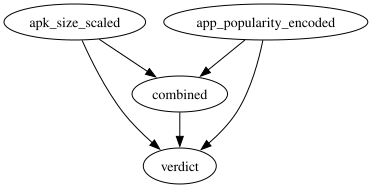

ATE: -0.10575635876840696
95% CI: (-0.24899598393574296, -0.07295850066934403)

Refuter: random_common_cause
Refute: Add a random common cause
Estimated effect:-0.10575635876840696
New effect:-0.10575635876840694
p value:1.0


Refuter: placebo_treatment_refuter
Refute: Use a Placebo Treatment
Estimated effect:-0.10575635876840696
New effect:-0.00015729585006693387
p value:0.99


Refuter: data_subset_refuter
Refute: Use a subset of data
Estimated effect:-0.10575635876840696
New effect:-0.05908786610878661
p value:0.26


Refuter: dummy_outcome_refuter
Refute: Use a Dummy Outcome
Estimated effect:0
New effect:0.005582390870234171
p value:0.97


-------------- Utilities vs App_Source_Code --------------

combined -> verdict (Spearman)
rho = -0.1901, p = 0.0000

combined
1    996
0    498
Name: count, dtype: int64


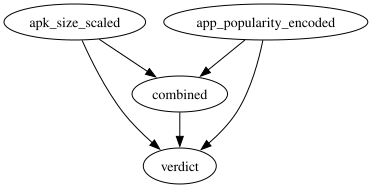

ATE: -0.18473895582329317
95% CI: (-0.28714859437751006, -0.10307898259705489)

Refuter: random_common_cause
Refute: Add a random common cause
Estimated effect:-0.18473895582329317
New effect:-0.18473895582329317
p value:1.0


Refuter: placebo_treatment_refuter
Refute: Use a Placebo Treatment
Estimated effect:-0.18473895582329317
New effect:-0.0025401606425702818
p value:0.98


Refuter: data_subset_refuter
Refute: Use a subset of data
Estimated effect:-0.18473895582329317
New effect:-0.1708033472803347
p value:0.78


Refuter: dummy_outcome_refuter
Refute: Use a Dummy Outcome
Estimated effect:0
New effect:0.003229350904432069
p value:0.99


-------------- Android vs App_Source_Code --------------

combined -> verdict (Spearman)
rho = 0.0458, p = 0.0766

combined
1    996
0    498
Name: count, dtype: int64


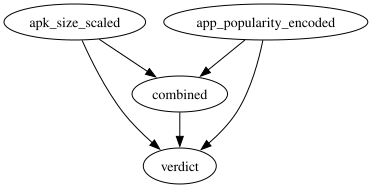

ATE: -0.002008032128514056
95% CI: (-0.09370816599732262, 0.07429718875502009)

Refuter: random_common_cause
Refute: Add a random common cause
Estimated effect:-0.002008032128514056
New effect:-0.0020080321285140565
p value:1.0


Refuter: placebo_treatment_refuter
Refute: Use a Placebo Treatment
Estimated effect:-0.002008032128514056
New effect:0.006676706827309237
p value:0.925


Refuter: data_subset_refuter
Refute: Use a subset of data
Estimated effect:-0.002008032128514056
New effect:0.0029288702928870285
p value:0.8999999999999999


Refuter: dummy_outcome_refuter
Refute: Use a Dummy Outcome
Estimated effect:0
New effect:0.001482548944460183
p value:0.98


-------------- Small_Libraries vs App_Source_Code --------------

combined -> verdict (Spearman)
rho = 0.1387, p = 0.0000

combined
1    996
0    498
Name: count, dtype: int64


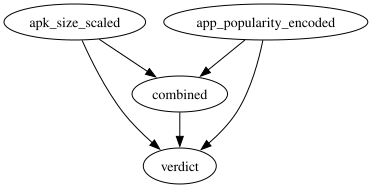

ATE: 0.008032128514056224
95% CI: (-0.12583668005354753, 0.04417670682730923)

Refuter: random_common_cause
Refute: Add a random common cause
Estimated effect:0.008032128514056224
New effect:0.008032128514056226
p value:1.0


Refuter: placebo_treatment_refuter
Refute: Use a Placebo Treatment
Estimated effect:0.008032128514056224
New effect:0.005645917001338687
p value:0.8799999999999999


Refuter: data_subset_refuter
Refute: Use a subset of data
Estimated effect:0.008032128514056224
New effect:0.057619246861924676
p value:0.20999999999999996


Refuter: dummy_outcome_refuter
Refute: Use a Dummy Outcome
Estimated effect:0
New effect:0.003411799133584527
p value:0.97



In [13]:
main_rows = []
ref_rows_all = []

for lib in libs:
    if lib == baseline_name:
        continue

    df_balanced = make_pairwise_balanced(df, lib, baseline=baseline_name, random_state=100)
    main_row, ref_rows = run_library_contrast(df_balanced, lib, baseline=baseline_name, label="balanced")
    main_rows.append(main_row)
    ref_rows_all.extend(ref_rows)


In [14]:
main_df = pd.DataFrame(main_rows).sort_values(["library", "setting"])
ref_df = pd.DataFrame(ref_rows_all)

print("\n\n" + "-" * 25 + " Detailed (ATEs) " + "-" * 25)
print(main_df[["library", "setting", "n_baseline", "n_treatment", "common_causes", "ATE", "CI_low", "CI_high"]])

pivot = main_df.pivot(index="library", columns="setting", values="ATE")
print("\n\n" + "-" * 25 + " Summary ATE " + "-" * 25)
print(pivot)




------------------------- Detailed (ATEs) -------------------------
           library   setting  n_baseline  n_treatment  \
2          Android  balanced         498          996   
3  Small_Libraries  balanced         498          996   
1        Utilities  balanced         498          996   
0    miscellaneous  balanced         498          996   

                             common_causes       ATE    CI_low   CI_high  
2  apk_size_scaled, app_popularity_encoded -0.002008 -0.093708  0.074297  
3  apk_size_scaled, app_popularity_encoded  0.008032 -0.125837  0.044177  
1  apk_size_scaled, app_popularity_encoded -0.184739 -0.287149 -0.103079  
0  apk_size_scaled, app_popularity_encoded -0.105756 -0.248996 -0.072959  


------------------------- Summary ATE -------------------------
setting          balanced
library                  
Android         -0.002008
Small_Libraries  0.008032
Utilities       -0.184739
miscellaneous   -0.105756
